# Assom — **per-bat** exact reproduction (bat_215 / bat_231)

This notebook mirrors Luigi Assom's `decodingNonHumanCommunication/` pipeline as
closely as his code allows, with every parameter and formula traced back to a
file + cell in his repo. The pivotal difference from the earlier pooled
reproduction: **HP1 is evaluated on a single bat at a time**, which is how
Assom actually runs `Exp1 - Classifier.ipynb` (`BAT_ID = 'bat_215'`).

References:
- `0.3 - Segment Blackboard.ipynb` (L111) — per-bat filter query
- `TF_AE.ipynb` — `LogMelSpectrogram` + UMAP params
- `UMAP_comparisons.ipynb` — HDBSCAN (L27) and NCA noise reassignment
- `Exp1 - Classifier.ipynb` — 18 features (L560–792), SVC grid (L1028–1074),
  within-sequence permutation (L1000).

**Switch bat by changing `TARGET_BAT` below.** Rerun the whole notebook.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
import os
import math
import zipfile
import collections
from collections import Counter, defaultdict
from itertools import pairwise, combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import umap
import hdbscan
import networkx as nx

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
    f1_score, accuracy_score, precision_score, make_scorer,
    confusion_matrix, ConfusionMatrixDisplay,
)
from sklearn.svm import SVC
from sklearn.model_selection import (
    StratifiedKFold, GridSearchCV, cross_val_predict, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, NeighborhoodComponentsAnalysis
from skimage.transform import resize
from scipy import signal as scipy_signal
from scipy.stats import ranksums

import soundfile as sf
from tqdm.auto import tqdm

print('Imports OK')


Imports OK


## 1. Config — one knob, the bat ID

Everything else is locked to Assom's published values.


In [2]:
# ── Per-bat target (change this and re-run the whole notebook) ───────────────
TARGET_BAT = 215     # or 231

# Per-bat context filter, from `0.3 - Segment Blackboard.ipynb` line 111:
#   'Context not in [0,11,6,12] and Emitter in [<BAT>] and Addressee  not in [0]'
# i.e. exclude Unknown (0), General (11), Isolation (6), Sleeping (12).
EXCLUDED_CONTEXT_IDS = [0, 11, 6, 12]
REQUIRE_KNOWN_ADDRESSEE = True

# Contexts kept for HP1 classification after sequence build — matches
# `Exp1 - Classifier.ipynb` L965 minus Isolation (6) which is already excluded
# per-bat. Net: [1 Separation, 2 Biting, 3 Feeding, 4 Fighting, 5 Grooming,
#                7 Kissing, 9 Mating protest, 10 Threat-like].
HP1_CONTEXTS_KEEP = [1, 2, 3, 4, 5, 7, 9, 10]

# ── Data location ────────────────────────────────────────────────────────────
DATA_DIR = Path('/Volumes/T7/data/raw/fruitbat')

# ── Audio ────────────────────────────────────────────────────────────────────
SR = 250_000

# ── LogMelSpectrogram, verbatim from TF_AE.ipynb ────────────────────────────
TF_FFT_SIZE   = 1024
TF_HOP_SIZE   = 1024
TF_FFT_LENGTH = 16384
TF_N_MELS     = 128
TF_FMIN       = 500
TF_FMAX       = 120_000
TF_NORMALIZE  = 'tanh'
TF_SPEC_BATCH_SIZE = 32
NORM_ADAPT_N  = 2048

# ── Resize to (21, 32) = 672-D flat features (the paper's 'coarse-graining') ─
SPEC_TIME = 21
SPEC_FREQ = 32

# ── Dynamic threshold segmentation, from fruit_bat_segment-all-2.0.ipynb ────
DYN_SEG_PARAMS = dict(
    n_fft=1024,
    hop_length_ms=0.5,
    win_length_ms=4,
    ref_level_db=20,
    pre=0.97,
    min_level_db=-30,
    silence_threshold=0.1,
    min_silence_for_spec=0.1,
    max_vocal_for_spec=1.0,
    min_syllable_length_s=0.01,
    spectral_range=[5000, 60000],
    min_level_db_floor=20,
    verbose=False,
)

# ── UMAP — TF_AE.ipynb cell 435 ─────────────────────────────────────────────
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST    = 0.3
UMAP_METRIC      = 'euclidean'
UMAP_SEED        = 0

# ── HDBSCAN — UMAP_comparisons.ipynb L27 ────────────────────────────────────
HDBSCAN_MIN_CLUSTER_FRAC = 0.02
HDBSCAN_MIN_SAMPLES      = 20
HDBSCAN_EPSILON          = 0.1
HDBSCAN_METHOD           = 'leaf'

# ── NCA noise reassignment — UMAP_comparisons.ipynb L751 ────────────────────
NCA_N_NEIGHBORS = 30

# ── Misc ────────────────────────────────────────────────────────────────────
IQR_K = 1.5
RANDOM_STATE = 0   # Assom uses _RANDOM_STATE = 0

CONTEXT_DICT = {
    0: 'Unknown',    1: 'Separation',   2: 'Biting',        3: 'Feeding',
    4: 'Fighting',   5: 'Grooming',     6: 'Isolation',     7: 'Kissing',
    8: 'Landing',    9: 'Mating protest', 10: 'Threat-like',
    11: 'General',   12: 'Sleeping',
}
CONTEXT_DICT_INV = {v: k for k, v in CONTEXT_DICT.items()}

print(f'Target bat: {TARGET_BAT}')
print(f'Excluded contexts: {[CONTEXT_DICT[c] for c in EXCLUDED_CONTEXT_IDS]}')
print(f'HP1 kept contexts: {[CONTEXT_DICT[c] for c in HP1_CONTEXTS_KEEP]}')


Target bat: 215
Excluded contexts: ['Unknown', 'General', 'Isolation', 'Sleeping']
HP1 kept contexts: ['Separation', 'Biting', 'Feeding', 'Fighting', 'Grooming', 'Kissing', 'Mating protest', 'Threat-like']


## 2. Annotations → per-bat filtered rows

Reproduces `'Context not in [0,11,6,12] and Emitter in [<BAT>] and Addressee not in [0]'`.


In [3]:
ann = pd.read_csv(DATA_DIR / 'Annotations.csv', low_memory=False)
print(f'Annotations: {ann.shape}')

with open(DATA_DIR / 'FileInfo.csv') as f:
    max_cols = max(len(line.split(',')) for line in f)
fi = pd.read_csv(DATA_DIR / 'FileInfo.csv', header=None,
                 names=[f'c{i}' for i in range(max_cols)], low_memory=False)
fi.columns = fi.iloc[0].values
fi = fi.iloc[1:].reset_index(drop=True)
fi['FileID'] = fi['FileID'].astype(int)
fi = fi[['FileID', 'File name', 'File folder']].drop_duplicates('FileID')
print(f'FileInfo: {fi.shape}')

ann['FileID'] = ann['FileID'].astype(int)
df = ann.merge(fi, on='FileID', how='inner')

df['Emitter']   = pd.to_numeric(df['Emitter'], errors='coerce')
df['Addressee'] = pd.to_numeric(df['Addressee'], errors='coerce')
df['Context']   = pd.to_numeric(df['Context'], errors='coerce')

# ── Assom's per-bat filter ───────────────────────────────────────────────────
df = df[df['Emitter'] == TARGET_BAT]
if REQUIRE_KNOWN_ADDRESSEE:
    df = df[df['Addressee'] > 0]
df = df[~df['Context'].isin(EXCLUDED_CONTEXT_IDS)]

df = df.dropna(subset=['Start sample', 'End sample', 'Context'])
df['Start sample'] = df['Start sample'].astype(int)
df['End sample']   = df['End sample'].astype(int)
df['Context']      = df['Context'].astype(int)
df['Context_name'] = df['Context'].map(CONTEXT_DICT)

print(f'\nFiltered annotations (Emitter={TARGET_BAT}): {len(df)}')
print(f'Context distribution:\n{df.Context_name.value_counts()}')
print(f'Addressee distribution:\n{df.Addressee.value_counts().head(10)}')


Annotations: (91080, 10)
FileInfo: (293238, 3)

Filtered annotations (Emitter=215): 1205
Context distribution:
Context_name
Mating protest    629
Biting            292
Feeding            90
Fighting           50
Kissing            48
Threat-like        48
Grooming           47
Landing             1
Name: count, dtype: int64
Addressee distribution:
Addressee
207    599
208    162
220    137
221    115
230     84
231     66
210     24
211     18
Name: count, dtype: int64


## 3. Load audio segments


In [4]:
zip_cache = {}

def get_zip(folder):
    if folder not in zip_cache:
        zp = DATA_DIR / f'{folder}.zip'
        zip_cache[folder] = zipfile.ZipFile(zp, 'r') if zp.exists() else None
    return zip_cache[folder]

segments, skipped = [], 0
grouped = df.groupby('FileID')

for file_id, group in tqdm(grouped, total=grouped.ngroups, desc='Loading WAVs'):
    row0 = group.iloc[0]
    folder = str(row0['File folder']).strip()
    fname  = str(row0['File name']).strip()

    zf = get_zip(folder)
    if zf is None:
        skipped += len(group); continue
    try:
        wav_bytes = zf.read(fname)
        audio_full, file_sr = sf.read(io.BytesIO(wav_bytes), dtype='float32')
    except Exception:
        skipped += len(group); continue

    for _, r in group.iterrows():
        s, e = int(r['Start sample']), int(r['End sample'])
        if e > len(audio_full) or s >= e:
            skipped += 1; continue
        seg = audio_full[s:e]
        if len(seg) < 100:
            skipped += 1; continue
        segments.append({
            'audio': seg,
            'sr': file_sr,
            'duration_s': len(seg) / file_sr,
            'context': int(r['Context']),
            'context_name': r['Context_name'],
            'emitter': int(r['Emitter']),
            'addressee': int(r['Addressee']) if pd.notna(r['Addressee']) else -1,
            'file_name': fname,
            'file_id': file_id,
        })

for z in zip_cache.values():
    if z is not None: z.close()
zip_cache.clear()

seg_df = pd.DataFrame(segments)
print(f'\nSegments loaded: {len(seg_df)} | skipped: {skipped}')
print(seg_df['duration_s'].describe())


Loading WAVs:   0%|          | 0/1202 [00:00<?, ?it/s]


Segments loaded: 1205 | skipped: 0
count    1205.000000
mean        2.125777
std         2.079628
min         0.089348
25%         1.314108
50%         1.445180
75%         2.166076
max        26.905916
Name: duration_s, dtype: float64


## 4. Dynamic threshold segmentation

Splits each annotated vocalisation into its component syllables.
Same params as `fruit_bat_segment-all-2.0.ipynb`.


In [5]:
from vocalseg.dynamic_thresholding import dynamic_threshold_segmentation

sub_segments, dyn_fail = [], 0
for i in tqdm(range(len(seg_df)), desc='Dynamic segmentation'):
    row = seg_df.iloc[i]
    audio, rate = row['audio'], int(row['sr'])
    try:
        results = dynamic_threshold_segmentation(audio, rate, **DYN_SEG_PARAMS)
    except Exception:
        results = None

    made_any = False
    if results is not None and len(results.get('onsets', [])) > 0:
        for onset_s, offset_s in zip(results['onsets'], results['offsets']):
            si, ei = int(onset_s * rate), int(offset_s * rate)
            sub = audio[si:ei]
            if len(sub) < 50:
                continue
            sub_segments.append({**{k: row[k] for k in
                                    ['context','context_name','emitter','addressee','file_name','file_id']},
                                 'audio': sub,
                                 'sr': rate,
                                 'duration_s': len(sub) / rate,
                                 'parent_start': si,
                                 'parent_end': ei})
            made_any = True

    if not made_any:
        dyn_fail += 1
        sub_segments.append({**{k: row[k] for k in
                                ['context','context_name','emitter','addressee','file_name','file_id']},
                             'audio': audio,
                             'sr': rate,
                             'duration_s': len(audio) / rate,
                             'parent_start': 0,
                             'parent_end': len(audio)})

seg_df = pd.DataFrame(sub_segments)
del sub_segments
print(f'After dynamic segmentation: {len(seg_df)} | fallback (whole segment): {dyn_fail}')
print(seg_df['duration_s'].describe())


Dynamic segmentation:   0%|          | 0/1205 [00:00<?, ?it/s]

After dynamic segmentation: 5027 | fallback (whole segment): 59
count    5027.000000
mean        0.066683
std         0.148194
min         0.010000
25%         0.019500
50%         0.034000
75%         0.072000
max         2.526524
Name: duration_s, dtype: float64


## 5. IQR filtering on segment duration


In [6]:
durations = seg_df['duration_s'].values
q1, q3 = np.percentile(durations, [25, 75])
iqr = q3 - q1
lo, hi = q1 - IQR_K * iqr, q3 + IQR_K * iqr
mask = (seg_df['duration_s'] >= max(lo, 0.001)) & (seg_df['duration_s'] <= hi)
print(f'IQR bounds: [{max(lo, 0.001):.4f}s, {hi:.4f}s]')
print(f'Kept {mask.sum()} / {len(seg_df)}')
seg_df = seg_df[mask].reset_index(drop=True)
# position within file for sequence ordering
seg_df['pos_segment'] = seg_df.groupby('file_name').cumcount()
print(seg_df['context_name'].value_counts())


IQR bounds: [0.0010s, 0.1507s]
Kept 4692 / 5027
context_name
Mating protest    2935
Biting             717
Fighting           377
Feeding            202
Threat-like        177
Kissing            148
Grooming           135
Landing              1
Name: count, dtype: int64


## 6. TF `LogMelSpectrogram` + resize → 672-D

`LogMelSpectrogram` is copied byte-for-byte from `TF_AE.ipynb`. The resize to
(21, 32) was inferred from the paper's stated 672 features (= 21 × 32).


In [7]:
class LogMelSpectrogram(keras.layers.Layer):
    """Verbatim from TF_AE.ipynb."""
    def __init__(self, sample_rate, fft_size, hop_size, fft_length, window_fn,
                 n_mels, f_min=0.0, f_max=None, normalize=None, **kwargs):
        super().__init__(**kwargs)
        self.sample_rate = sample_rate
        self.fft_size = fft_size
        self.hop_size = hop_size
        self.fft_length = fft_length
        self.window_fn = window_fn
        self.n_mels = n_mels
        self.f_min = f_min
        self.f_max = f_max if f_max else sample_rate / 2
        self.normalize = normalize
        self.mel_filterbank = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.n_mels,
            num_spectrogram_bins=self.fft_length // 2 + 1,
            sample_rate=self.sample_rate,
            lower_edge_hertz=self.f_min,
            upper_edge_hertz=self.f_max,
        )

    def build(self, input_shape):
        self.non_trainable_weights.append(self.mel_filterbank)
        super().build(input_shape)

    def call(self, waveforms):
        def _tf_log10(x):
            num = tf.math.log(x)
            den = tf.math.log(tf.constant(10, dtype=num.dtype))
            return num / den

        def _normalize(log_mel, scaler=self.normalize):
            min_v = tf.math.reduce_min(log_mel, axis=3, keepdims=True)
            max_v = tf.math.reduce_max(log_mel, axis=3, keepdims=True)
            if scaler == 'tanh':
                out = 2.0 * (log_mel - min_v) / (max_v - min_v + 1e-7) - 1.0
                nan_val = -1.0
            elif scaler == 'sigmoid':
                out = (log_mel - min_v) / (max_v - min_v + 1e-7)
                nan_val = 0.0
            else:
                return log_mel
            idx = tf.where(tf.math.is_nan(out))
            out = tf.tensor_scatter_nd_update(
                out, idx, tf.ones(tf.shape(idx)[0], dtype=out.dtype) * nan_val
            )
            return out

        def power_to_db(magnitude, amin=1e-16, top_db=120.0):
            ref = tf.reduce_max(magnitude)
            log_spec = 10.0 * _tf_log10(tf.maximum(amin, magnitude))
            log_spec -= 10.0 * _tf_log10(tf.maximum(amin, ref))
            log_spec = tf.maximum(log_spec, tf.reduce_max(log_spec) - top_db)
            return log_spec

        spectrograms = tf.signal.stft(
            waveforms, frame_length=self.fft_size, frame_step=self.hop_size,
            fft_length=self.fft_length, pad_end=True,
        )
        magnitude = tf.abs(spectrograms)
        mel = tf.matmul(tf.square(magnitude), self.mel_filterbank)
        log_mel = power_to_db(mel)
        log_mel = _normalize(log_mel)
        sh = tf.shape(log_mel)
        return tf.reshape(log_mel, [-1, sh[2], sh[3]])


def _resample_audio(y, sr_from, sr_to):
    y = np.asarray(y, dtype=np.float32)
    if sr_from == sr_to:
        return y
    n_out = max(1, int(len(y) * sr_to / sr_from))
    return scipy_signal.resample(y, n_out).astype(np.float32)


def _pad_mean(y, target_len):
    y = np.asarray(y, dtype=np.float32)
    if len(y) >= target_len:
        return y[:target_len]
    pad_val = float(np.mean(y)) if len(y) else 0.0
    return np.pad(y, (0, target_len - len(y)), mode='constant', constant_values=pad_val)


max_len = int(seg_df['audio'].apply(len).max())
print(f'Padded waveform length: {max_len} samples @ SR={SR}')

log_mel_layer = LogMelSpectrogram(
    sample_rate=SR, fft_size=TF_FFT_SIZE, hop_size=TF_HOP_SIZE,
    fft_length=TF_FFT_LENGTH, window_fn=tf.signal.hamming_window,
    n_mels=TF_N_MELS, f_min=TF_FMIN, f_max=TF_FMAX,
    normalize=TF_NORMALIZE, name='LogMel',
)
norm_layer = layers.Normalization(axis=-1, name='Normalization')

inp = keras.Input(shape=(max_len,), dtype=tf.float32, name='waveform')
x = layers.Reshape((1, -1), name='Flatten')(inp)
x = log_mel_layer(x)
x = norm_layer(x)
preprocess_model = keras.Model(inp, x, name='preprocess_model')
preprocess_model.compile()

n_adapt = min(NORM_ADAPT_N, len(seg_df))
adapt_wavs = [
    _pad_mean(_resample_audio(seg_df.iloc[i]['audio'], int(seg_df.iloc[i]['sr']), SR), max_len)
    for i in range(n_adapt)
]
adapt_X = np.stack(adapt_wavs, axis=0).astype(np.float32)
print(f'Adapting Normalization on {adapt_X.shape[0]} padded waveforms...')
with tf.device('/CPU:0'):
    mel_adapt = log_mel_layer(layers.Reshape((1, -1))(tf.constant(adapt_X)))
norm_layer.adapt(mel_adapt)
print('Normalization adapted.')

n = len(seg_df)
tf_specs = np.zeros((n, SPEC_TIME, SPEC_FREQ), dtype=np.float32)
for start in tqdm(range(0, n, TF_SPEC_BATCH_SIZE), desc='TF preprocess_model'):
    end = min(start + TF_SPEC_BATCH_SIZE, n)
    batch = np.stack([
        _pad_mean(_resample_audio(seg_df.iloc[i]['audio'], int(seg_df.iloc[i]['sr']), SR), max_len)
        for i in range(start, end)
    ], axis=0).astype(np.float32)
    out = preprocess_model.predict(batch, verbose=0)
    for j, i in enumerate(range(start, end)):
        tf_specs[i] = resize(out[j], (SPEC_TIME, SPEC_FREQ),
                             mode='constant', anti_aliasing=True).astype(np.float32)

print(f'tf_specs shape: {tf_specs.shape}  |  {SPEC_TIME*SPEC_FREQ} features')


Padded waveform length: 37625 samples @ SR=250000
Adapting Normalization on 2048 padded waveforms...
Normalization adapted.


TF preprocess_model:   0%|          | 0/147 [00:00<?, ?it/s]

tf_specs shape: (4692, 21, 32)  |  672 features


In [8]:
seg_df = seg_df.drop(columns=['audio', 'sr']).reset_index(drop=True)
import gc; gc.collect()
print(f'seg_df columns: {list(seg_df.columns)}')
print(f'tf_specs memory: {tf_specs.nbytes / 1e6:.1f} MB')


seg_df columns: ['context', 'context_name', 'emitter', 'addressee', 'file_name', 'file_id', 'duration_s', 'parent_start', 'parent_end', 'pos_segment']
tf_specs memory: 12.6 MB


## 7. UMAP (2-D for plotting & density clustering)

Params from `TF_AE.ipynb` cell 435:
`UMAP(n_components=2, n_neighbors=30, min_dist=0.3, metric='euclidean', random_state=0)`


In [9]:
X_flat = tf_specs.reshape(len(tf_specs), -1)
print(f'Input to UMAP: {X_flat.shape}')

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=UMAP_N_NEIGHBORS,
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=UMAP_SEED,
    n_jobs=-1,
)
embedding = reducer.fit_transform(X_flat)
print(f'UMAP embedding: {embedding.shape}')


Input to UMAP: (4692, 672)
UMAP embedding: (4692, 2)


## 8. HDBSCAN

Exact params from `UMAP_comparisons.ipynb` L27:
```python
hdbscan.HDBSCAN(min_cluster_size=int(len(z)*0.02),
                min_samples=20,
                cluster_selection_epsilon=0.1,
                cluster_selection_method='leaf',
                prediction_data=True)
```


In [10]:
N = len(embedding)
mcs = max(int(N * HDBSCAN_MIN_CLUSTER_FRAC), 10)
print(f'N={N}, min_cluster_size={mcs}')

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=mcs,
    min_samples=HDBSCAN_MIN_SAMPLES,
    cluster_selection_epsilon=HDBSCAN_EPSILON,
    cluster_selection_method=HDBSCAN_METHOD,
    prediction_data=True,
).fit(embedding)

hdbscan_labels = clusterer.labels_
n_clusters = len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)
n_noise = int((hdbscan_labels == -1).sum())
print(f'HDBSCAN clusters: {n_clusters}   noise: {n_noise} ({100*n_noise/N:.1f}%)')

if n_clusters >= 2:
    nn = hdbscan_labels >= 0
    print(f'Silhouette (excl. noise): {silhouette_score(embedding[nn], hdbscan_labels[nn]):.3f}')


N=4692, min_cluster_size=93
HDBSCAN clusters: 21   noise: 806 (17.2%)
Silhouette (excl. noise): 0.612


## 9. NCA noise reassignment

Direct port of `reassign_hdb_noise_nca` from `UMAP_comparisons.ipynb`
with `n_neighbors=30` (the call at L751).


In [11]:
def reassign_hdb_noise_nca(hdb_clusterer, umap_embedding, n_neighbors=NCA_N_NEIGHBORS):
    """Verbatim from UMAP_comparisons.ipynb."""
    pipe = Pipeline([
        ('nca', NeighborhoodComponentsAnalysis(random_state=RANDOM_STATE)),
        ('knn', KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform', n_jobs=-1)),
    ])

    ix_not_noise = np.argwhere(hdb_clusterer.labels_ > -1).flatten()
    ix_noise     = np.argwhere(hdb_clusterer.labels_ == -1).flatten()

    y_train = np.take(hdb_clusterer.labels_, ix_not_noise)
    X_train = np.vstack(np.take(umap_embedding, ix_not_noise, axis=0))
    X_noise = np.vstack(np.take(umap_embedding, ix_noise, axis=0)) if len(ix_noise) else np.empty((0, umap_embedding.shape[1]))

    ext = np.array(list(hdb_clusterer.labels_).copy())
    if len(ix_noise) == 0:
        return ext
    try:
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_noise)
    except Exception as e:
        print(f'NCA failed: {e}; using KNN only')
        knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights='uniform', n_jobs=-1)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_noise)
    ext[ix_noise] = y_pred
    return ext


hdb_nca_labels = reassign_hdb_noise_nca(clusterer, embedding)
seg_df['syllable_id'] = hdb_nca_labels
print(f'Final clusters after NCA reassignment: {len(set(hdb_nca_labels))}')
print(pd.Series(hdb_nca_labels).value_counts().sort_index())


Final clusters after NCA reassignment: 21
0     339
1     143
2     257
3     152
4     279
5     109
6     203
7     106
8     171
9     355
10    150
11    126
12    113
13    299
14    118
15    135
16    445
17    290
18    348
19    198
20    356
Name: count, dtype: int64


## 10. UMAP visualisation


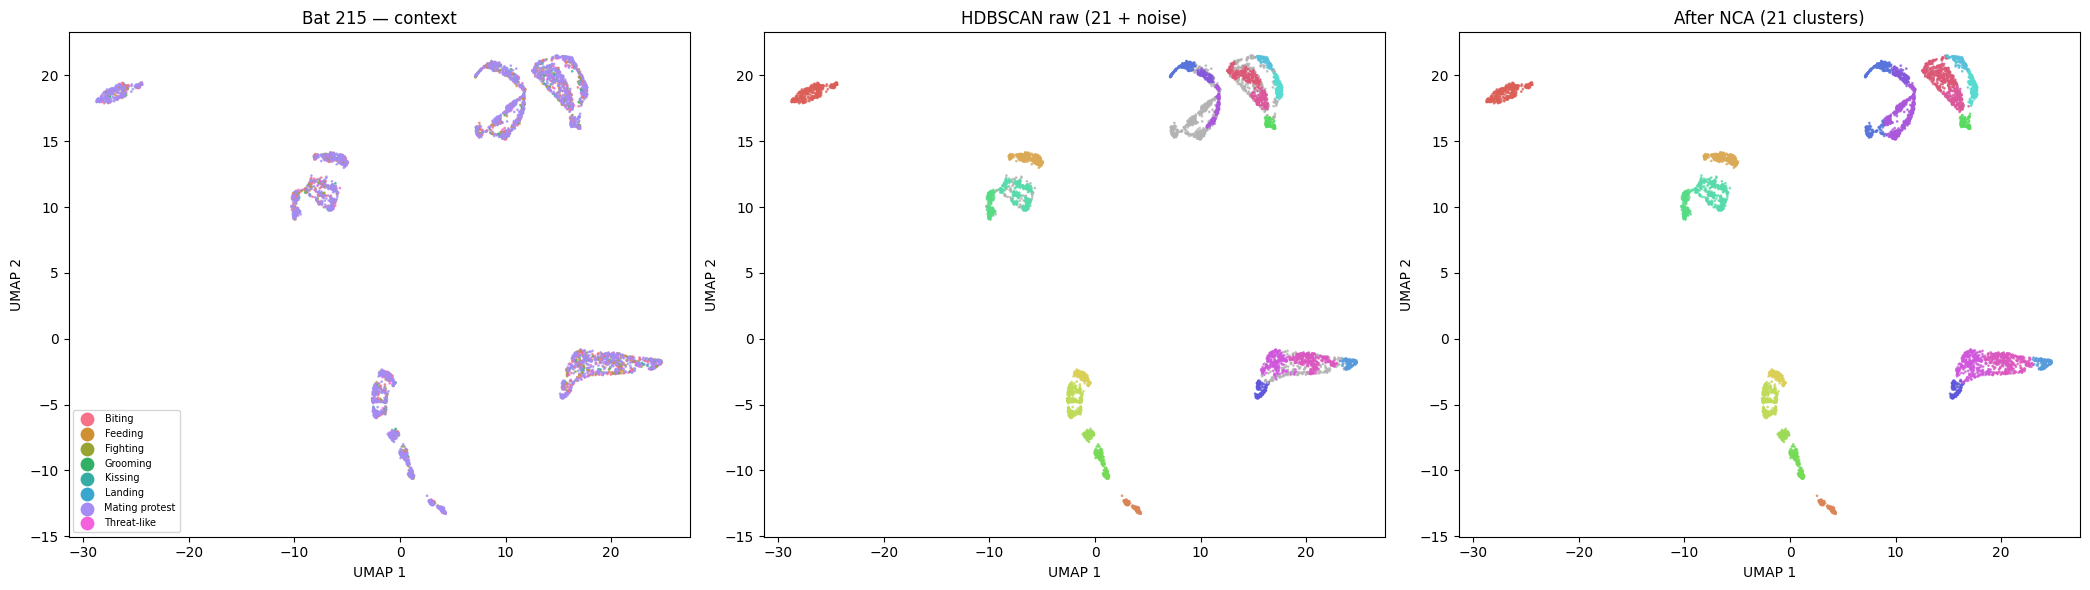

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# 1) By context
ctx_labels = seg_df['context_name'].values
uniq_ctx = sorted(set(ctx_labels))
pal_ctx = sns.color_palette('husl', len(uniq_ctx))
cmap_ctx = dict(zip(uniq_ctx, pal_ctx))
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=[cmap_ctx[c] for c in ctx_labels], s=1.0, alpha=0.7)
for c in uniq_ctx:
    axes[0].scatter([], [], c=[cmap_ctx[c]], label=c, s=20)
axes[0].legend(fontsize=7, markerscale=2)
axes[0].set_title(f'Bat {TARGET_BAT} — context')

# 2) HDBSCAN raw
n_raw = max(hdbscan_labels) + 1
pal_hdb = sns.color_palette('hls', max(n_raw, 1))
axes[1].scatter(embedding[:, 0], embedding[:, 1],
                c=[(.7,.7,.7) if l == -1 else pal_hdb[l] for l in hdbscan_labels],
                s=1.0, alpha=0.7)
axes[1].set_title(f'HDBSCAN raw ({n_clusters} + noise)')

# 3) NCA reassigned
n_final = max(hdb_nca_labels) + 1
pal_nca = sns.color_palette('hls', max(n_final, 1))
axes[2].scatter(embedding[:, 0], embedding[:, 1],
                c=[pal_nca[l] for l in hdb_nca_labels], s=1.0, alpha=0.7)
axes[2].set_title(f'After NCA ({len(set(hdb_nca_labels))} clusters)')

for ax in axes:
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout(); plt.show()


## 11. Per-file sequences

`seq_mapped_bat_215.groupby('File name').apply(lambda x: x.sort_values('Pos_segment')['syllableID_hdb_nca'].tolist())`
— same thing, translated to our columns.


In [13]:
seq_rows = []
for fname, g in seg_df.groupby('file_name'):
    g_sorted = g.sort_values('pos_segment')
    syl = g_sorted['syllable_id'].tolist()
    if len(syl) < 2:
        continue
    ctx = Counter(g_sorted['context'].tolist()).most_common(1)[0][0]
    addr = Counter(g_sorted['addressee'].tolist()).most_common(1)[0][0]
    seq_rows.append({
        'file_name': fname,
        'hdb_nca': syl,
        'length': len(syl),
        'context': int(ctx),
        'context_name': CONTEXT_DICT[int(ctx)],
        'addressee': int(addr),
    })

SEQUENCES = pd.DataFrame(seq_rows).set_index('file_name')
SEQUENCES = SEQUENCES[SEQUENCES['context'].isin(HP1_CONTEXTS_KEEP)]
print(f'Sequences for bat {TARGET_BAT}: {len(SEQUENCES)}')
print(SEQUENCES['context_name'].value_counts())
print(f'\nSequence length:\n{SEQUENCES.length.describe()}')


Sequences for bat 215: 672
context_name
Mating protest    375
Biting            138
Feeding            44
Fighting           42
Grooming           26
Threat-like        24
Kissing            23
Name: count, dtype: int64

Sequence length:
count    672.000000
mean       6.279762
std        8.468175
min        2.000000
25%        2.000000
50%        3.000000
75%        7.000000
max       81.000000
Name: length, dtype: float64


## 12. The 18 features `(a–r)` — **verbatim from `Exp1 - Classifier.ipynb`**

Helper functions copied from lines 229–485, `prepare_data_from_sequences`
from lines 560–792, `make_graph_transitions` from lines 837–865.

The only adaptation: operating on our column `hdb_nca` and context column
`context` (both already set up to match Assom's schema).


In [14]:
# ── Assom helpers (verbatim, renamed paths where necessary) ────────────────

def linearity(sequence):
    num_seq = len(set(sequence))
    num_t = len(set([p for p in pairwise(sequence)]))
    return num_seq / num_t if num_t != 0 else 0


def consistency(sequence, num_transition_types_in_context):
    num_t = len(set([p for p in pairwise(sequence)]))
    return num_t / num_transition_types_in_context if num_transition_types_in_context else 0


def num_transition_types_in_context(df, context_id, context_type, alphabethType='hdb_nca'):
    seq_in_context = set()
    mask = df[context_type].apply(lambda x: x == context_id)
    for _, row in df[mask].iterrows():
        for p in pairwise(row[alphabethType]):
            seq_in_context.add(p)
    return len(seq_in_context)


def num_transitions_in_seq(sequence):
    return sum(Counter([p for p in pairwise(sequence)]).values())


def prob_syl_by_context(df, contextId, contextLabel, alphabethType='hdb_nca'):
    sub = df[df[contextLabel].apply(lambda x: contextId == x)]
    freq = sub[alphabethType].explode().value_counts()
    tot = freq.sum()
    return freq.apply(lambda x: x / tot).to_dict() if tot else {}


def entropy_order(sequence, prob_syl_by_context_, order):
    if order == 0:
        e = lambda x: prob_syl_by_context_[x] * np.log2(prob_syl_by_context_[x])                       if x in prob_syl_by_context_ and prob_syl_by_context_[x] > 0 else 0
        return -sum([e(s) for s in sequence])
    return 0


def compute_conditional_prob_1(series, n):
    cond_freqs = defaultdict(lambda: defaultdict(int))
    for seq in series:
        antecedents = []
        for i in range(n):
            if i < len(seq):
                antecedents.append(seq[i])
        for i in range(len(seq)):
            item = seq[i]
            cond_freqs[tuple(antecedents)][item] += 1
            if len(antecedents) >= n:
                antecedents.pop(0)
            antecedents.append(item)
    cond_probs = {}
    for cond_key, freq_dict in cond_freqs.items():
        tot = sum(freq_dict.values())
        cond_probs[cond_key] = {item: f / tot for item, f in freq_dict.items()}
    return cond_probs


def conditional_prob_of_seq(sequence, conditional_prob_dict, initial_states):
    if len(sequence) == 0:
        return 0
    state_0 = sequence[0]
    p_cond = initial_states.get(state_0, 1e-4)
    for i in range(1, len(sequence)):
        antecedent = sequence[i - 1]
        current = sequence[i]
        key = (antecedent,)
        if key in conditional_prob_dict and current in conditional_prob_dict[key]:
            p_cond *= conditional_prob_dict[key][current]
    return p_cond


def transitions_dict(sequences):
    tr = sequences.apply(lambda x: [p for p in pairwise(x)]).explode().value_counts()
    tot = tr.sum()
    return tr.apply(lambda x: x / tot).to_dict() if tot else {}


def transitions_in_context(sequence, transitions):
    try:
        t_prob = math.prod([transitions[p] for p in pairwise(sequence)])
    except Exception:
        probs = [transitions[p] for p in pairwise(sequence) if p in transitions]
        t_prob = math.prod(probs) if len(probs) > 1 else 0
    return t_prob if t_prob != 1 else 0


def num_syllables_type_in_seq(sequence):
    return len(set(sequence))


def num_all_syllables_type(sequence):
    return sum([sequence.count(i) for i in set(sequence)])


def compute_transition_prob(series):
    graph = nx.DiGraph()
    for seq in series:
        for i in range(len(seq) - 1):
            s, t = seq[i], seq[i + 1]
            if graph.has_edge(s, t):
                graph[s][t]['weight'] += 1
            else:
                graph.add_edge(s, t, weight=1)
    trans_probs = {}
    for src in graph.nodes():
        tot = sum(graph[src][t]['weight'] for t in graph.successors(src))
        trans_probs[src] = {t: graph[src][t]['weight'] / tot for t in graph.successors(src)} if tot else {}
    return trans_probs


def uncertainty_transitions(sequence, transition_probabilities):
    if len(sequence) < 2:
        return 0
    probs = 0
    for p in pairwise(sequence):
        curr, post = p
        if curr in transition_probabilities and post in transition_probabilities[curr]:
            tp = transition_probabilities[curr][post]
            if tp > 0:
                probs += tp * np.log2(tp)
    return -probs


def _conditional_p_edge(edge, freq_edge, edges):
    current = edge[1]
    antecedents = [e for e in edges if e[1] == current]
    return (freq_edge / len(antecedents)) if len(antecedents) else 1e-7


def _transitional_p_edge(edge, freq_edge, edges):
    current = edge[0]
    posteriors = [e for e in edges if e[0] == current]
    return (freq_edge / len(posteriors)) if len(posteriors) else 1e-7


def make_graph_transitions(SEQ_DF, alphabethType='hdb_nca'):
    G = nx.DiGraph()
    seq_series = SEQ_DF[alphabethType]
    total_syllables = len(seq_series.explode().unique())
    nodes = [(n, {'frequency': f, 'p_frequency': f / total_syllables})
             for n, f in seq_series.explode().value_counts().to_dict().items()]
    G.add_nodes_from(nodes)
    edges = [i for seq in seq_series for i in pairwise(seq)]
    counter = Counter(edges)
    for e, v in counter.items():
        G.add_edge(*e,
                   frequency=v,
                   p_frequency=v / len(edges),
                   p_cond=_conditional_p_edge(e, v, edges),
                   p_trans=_transitional_p_edge(e, v, edges))
    return G


In [15]:
def prepare_data_from_sequences(df, data_df, G, alphabethType='hdb_nca', sequences_in_context=True):
    """Verbatim from Exp1 - Classifier.ipynb lines 560–792."""
    columns = list(map(chr, range(97, 97 + 18)))  # a..r
    df_dict = {col: [] for col in columns}

    _transitions_in_context = {}
    _prob_syl_by_context = {}
    _cond_prob_by_context = {}
    _trans_probs = {}
    _transitions_dict = {}

    _alphabet = df[alphabethType].explode().unique()

    for contextId in df['context'].unique():
        _transitions_in_context[contextId] = num_transition_types_in_context(
            df, contextId, 'context', alphabethType=alphabethType
        )
        _prob_syl_by_context[contextId] = prob_syl_by_context(
            df, contextId, 'context', alphabethType=alphabethType
        )
        sequences = df[df['context'].apply(lambda x: contextId == x)][alphabethType]
        _cond_prob_by_context[contextId] = compute_conditional_prob_1(sequences, 1)
        _trans_probs[contextId] = compute_transition_prob(sequences)
        _transitions_dict[contextId] = transitions_dict(sequences)

    _cond_prob_all   = compute_conditional_prob_1(df[alphabethType], 1)
    _cond_prob_all_2 = compute_conditional_prob_1(df[alphabethType], 2)
    _transitions_dict_all = transitions_dict(df[alphabethType])
    _trans_probs_all = compute_transition_prob(df[alphabethType])
    _transitions_in_total = df[alphabethType].apply(
        lambda x: [p for p in pairwise(x)]
    ).explode().value_counts().sum()

    freq_syllables = df[alphabethType].explode().value_counts()
    total_freq = freq_syllables.sum()
    _prob_syl_in_total = freq_syllables.apply(lambda x: x / total_freq).to_dict() if total_freq else {}

    for i, row in data_df.iterrows():
        sequence = row[alphabethType]
        contextId = row['context']

        df_dict['a'].append(num_syllables_type_in_seq(sequence))                    # a
        df_dict['b'].append(num_all_syllables_type(sequence))                       # b
        df_dict['c'].append(num_transitions_in_seq(sequence))                       # c
        df_dict['d'].append(linearity(sequence))                                    # d

        if sequences_in_context:
            df_dict['e'].append(consistency(sequence, _transitions_in_context[contextId]))   # e
            df_dict['f'].append(entropy_order(sequence, _prob_syl_by_context[contextId], 0)) # f
            init_prob = _prob_syl_by_context[contextId]
            df_dict['g'].append(conditional_prob_of_seq(sequence, _cond_prob_by_context[contextId], init_prob))  # g
            df_dict['h'].append(transitions_in_context(sequence, _transitions_dict[contextId]))                  # h
            df_dict['j'].append(uncertainty_transitions(sequence, _trans_probs[contextId]))                      # j
        else:
            df_dict['e'].append(consistency(sequence, _transitions_in_total))
            df_dict['f'].append(entropy_order(sequence, _prob_syl_in_total, 0))
            init_prob = _prob_syl_in_total
            df_dict['g'].append(conditional_prob_of_seq(sequence, _cond_prob_all, init_prob))
            df_dict['h'].append(transitions_in_context(sequence, _transitions_dict_all))
            df_dict['j'].append(uncertainty_transitions(sequence, _trans_probs_all))

        # (i) versatility = a/b
        df_dict['i'].append(num_syllables_type_in_seq(sequence) / max(num_all_syllables_type(sequence), 1))

        # (k) product of transition probabilities from graph
        probs = []
        for p in pairwise(sequence):
            if p in G.edges:
                probs.append(G.edges[p]['p_trans'])
        df_dict['k'].append(math.prod(probs) if len(probs) > 0 else 0)

        # (l) product of p_cond * log2(p_cond) along edges
        probs = []
        for p in pairwise(sequence):
            if p in G.edges:
                pc = G.edges[p]['p_cond']
                if pc > 0:
                    probs.append(pc * np.log2(pc))
        df_dict['l'].append(math.prod(probs) if probs else 0)

        # (m) product of p_trans * log2(p_trans) along edges
        probs = []
        for p in pairwise(sequence):
            if p in G.edges:
                pt = G.edges[p]['p_trans']
                if pt > 0:
                    probs.append(pt * np.log2(pt))
        df_dict['m'].append(math.prod(probs) if probs else 0)

        # (n) 1-gram cond prob product (all-context)
        p_cond = []
        for idx, _ in enumerate(sequence):
            current = sequence[idx]
            if idx == 0:
                p_cond.append(init_prob.get(current, 1e-4))
            else:
                antecedent = sequence[idx - 1]
                if (antecedent,) in _cond_prob_all and current in _cond_prob_all[(antecedent,)]:
                    p_cond.append(_cond_prob_all[(antecedent,)][current])
                else:
                    p_cond.append(1e-4)
        df_dict['n'].append(math.prod(p_cond) if p_cond else 0)

        # (o) cond prob product from graph nodes, (p) transition prob product from graph edges
        p_cond, p_trans = [], []
        for idx, _ in enumerate(sequence):
            current = sequence[idx]
            if idx == 0:
                if current in G.nodes:
                    p_cond.append(G.nodes[current].get('p_frequency', 1e-4))
                else:
                    p_cond.append(1e-4)
            else:
                antecedent = sequence[idx - 1]
                if antecedent in G and current in G[antecedent]:
                    p_cond.append(G[antecedent][current]['p_cond'])
                else:
                    p_cond.append(1e-4)
                if idx < len(sequence) - 1:
                    successor = sequence[idx + 1]
                    if current in G and successor in G[current]:
                        p_trans.append(G[current][successor]['p_trans'])
                    else:
                        p_trans.append(1e-4)
        df_dict['o'].append(math.prod(p_cond) if p_cond else 0)
        df_dict['p'].append(math.prod(p_trans) if p_trans else 0)

        # (q) 2-gram conditional prob product
        p_cond = []
        for idx, _ in enumerate(sequence):
            current = sequence[idx]
            if idx == 0:
                p_cond.append(init_prob.get(current, 1e-4))
            else:
                antecedent = sequence[idx - 1]
                if (antecedent,) in _cond_prob_all and current in _cond_prob_all[(antecedent,)]:
                    p_cond.append(_cond_prob_all[(antecedent,)][current])
                if idx > 1:
                    second_antecedent = sequence[idx - 2]
                    if ((second_antecedent, antecedent) in _cond_prob_all_2
                            and current in _cond_prob_all_2[(second_antecedent, antecedent)]):
                        p_cond.append(_cond_prob_all_2[(second_antecedent, antecedent)][current])
                    else:
                        p_cond.append(1e-4)
        df_dict['q'].append(math.prod(p_cond) if p_cond else 0)

        # (r) perplexity
        if p_cond and all(p > 0 for p in p_cond):
            df_dict['r'].append(np.power(math.prod([1 / p for p in p_cond]), 1 / len(p_cond)))
        else:
            df_dict['r'].append(0)

    return pd.DataFrame.from_dict(df_dict)


## 13. Build feature matrix, run GridSearchCV, then the within-sequence permutation

SVC grid and CV scheme from `Exp1 - Classifier.ipynb` lines 1028–1074:

```python
param_grid = {
    'C': np.logspace(-3, 3, 7),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
```

`refit='f1_weighted'`.


In [16]:
ALPHABET = 'hdb_nca'

# The graph uses the same per-bat sequences (Assom's L967 uses ALL_SEQUENCES —
# for a per-bat run that's just our SEQUENCES).
G = make_graph_transitions(SEQUENCES, alphabethType=ALPHABET)

X = prepare_data_from_sequences(SEQUENCES, SEQUENCES, G,
                                alphabethType=ALPHABET,
                                sequences_in_context=True)
X.columns = X.columns.astype(str)
X = X.fillna(0).replace([np.inf, -np.inf], [1, 0])

y = SEQUENCES['context'].values
print(f'X shape: {X.shape}   y classes: {sorted(set(y))}')
print(pd.Series(y).value_counts())


X shape: (672, 18)   y classes: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(9), np.int64(10)]
9     375
2     138
3      44
4      42
5      26
10     24
7      23
Name: count, dtype: int64


In [17]:
# GridSearchCV as in Exp1 - Classifier.ipynb lines 1028–1074.
_RANDOM_STATE = RANDOM_STATE
param_grid = {
    'C': np.logspace(-3, 3, 7),
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto'],
}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=_RANDOM_STATE)
scoring = {
    'Accuracy':       make_scorer(accuracy_score),
    'f1_weighted':    make_scorer(f1_score, average='weighted'),
    'f1_micro':       make_scorer(f1_score, average='micro'),
    'precision_micro': make_scorer(precision_score, average='micro'),
    'recall_micro':   make_scorer(precision_score, average='micro'),
}

# Hold-out split — Assom uses train/val/test 75/25 then 75/25
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=_RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, stratify=y_train, test_size=0.25, random_state=_RANDOM_STATE)

sc = StandardScaler().fit(X_train)
X_train_std = sc.transform(X_train)
X_val_std   = sc.transform(X_val)
X_test_std  = sc.transform(X_test)

svm = SVC(probability=True)
grid = GridSearchCV(estimator=svm, param_grid=param_grid, scoring=scoring,
                    cv=cv, refit='f1_weighted', return_train_score=True,
                    verbose=1, n_jobs=-1)
grid.fit(X_train_std, y_train)
print(f'Best params: {grid.best_params_}')
print(f'Best CV f1_weighted: {grid.best_score_:.4f}')


Fitting 10 folds for each of 28 candidates, totalling 280 fits
Best params: {'C': np.float64(1000.0), 'gamma': 'scale', 'kernel': 'linear'}
Best CV f1_weighted: 0.8459


In [18]:
# Retrain on train+val, evaluate on held-out test (Assom's L1099 / L1108)
model = grid.best_estimator_
model.fit(np.concatenate([X_train_std, X_val_std]),
          np.concatenate([y_train, y_val]))
y_pred_orig = model.predict(X_test_std)
f1_orig  = f1_score(y_test, y_pred_orig, average='weighted')
acc_orig = accuracy_score(y_test, y_pred_orig)
print(f'=== HP1 original — bat_{TARGET_BAT} ===')
print(f'F1 (weighted): {f1_orig:.3f}')
print(f'Accuracy:      {acc_orig:.3f}')


=== HP1 original — bat_215 ===
F1 (weighted): 0.924
Accuracy:      0.929


### Permutation test — within-sequence shuffle

Exactly what Assom does (`Exp1 - Classifier.ipynb` L1000):

```python
permuted_pruned_df[ALPHABETH] = permuted_pruned_df[ALPHABETH].apply(
    lambda x: list(np.random.permutation(x))
)
```


In [19]:
rng = np.random.default_rng(_RANDOM_STATE)
permuted = SEQUENCES.copy()
permuted[ALPHABET] = permuted[ALPHABET].apply(lambda x: list(rng.permutation(x)))

# Build features for permuted set using the SAME unpermuted graph / context
# stats (per Assom: G, _cond_prob_by_context, etc. come from the original df).
X_perm = prepare_data_from_sequences(SEQUENCES, permuted, G,
                                     alphabethType=ALPHABET,
                                     sequences_in_context=True)
X_perm.columns = X_perm.columns.astype(str)
X_perm = X_perm.fillna(0).replace([np.inf, -np.inf], [1, 0])
X_perm_std = sc.transform(X_perm)
y_perm = permuted['context'].values

# X and X_perm share the same RangeIndex (0..N-1) — `prepare_data_from_sequences`
# returns a DataFrame with default index. `permuted` inherits `file_name` from
# SEQUENCES as its index, so use positional indexing to align rows.
test_pos = X_test.index.tolist()
X_perm_test = sc.transform(X_perm.iloc[test_pos])
y_perm_test = permuted.iloc[test_pos]['context'].values

y_pred_perm = model.predict(X_perm_test)
f1_perm  = f1_score(y_perm_test, y_pred_perm, average='weighted')
acc_perm = accuracy_score(y_perm_test, y_pred_perm)
print(f'=== HP1 permuted — bat_{TARGET_BAT} ===')
print(f'F1 (weighted): {f1_perm:.3f}')
print(f'Accuracy:      {acc_perm:.3f}')

print('\n=== HP1 summary ===')
print(f'Bat {TARGET_BAT} |  F1 orig = {f1_orig:.3f}  |  F1 perm = {f1_perm:.3f}  |  Δ = {f1_orig - f1_perm:+.3f}')
if abs(f1_orig - f1_perm) < 0.05:
    print('→ associative syntax (order does not matter)')
else:
    print('→ combinatorial syntax (order matters)')


=== HP1 permuted — bat_215 ===
F1 (weighted): 0.878
Accuracy:      0.881

=== HP1 summary ===
Bat 215 |  F1 orig = 0.924  |  F1 perm = 0.878  |  Δ = +0.046
→ associative syntax (order does not matter)


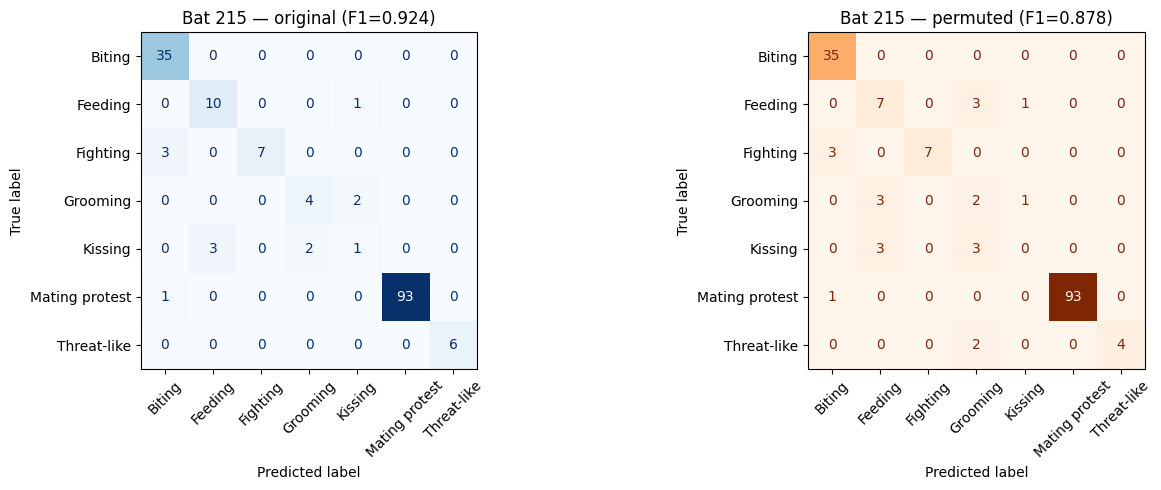

In [20]:
# Confusion matrices
le = LabelEncoder().fit(y)
disp_labels = [CONTEXT_DICT[c] for c in sorted(set(y))]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_o = confusion_matrix(y_test, y_pred_orig, labels=sorted(set(y)))
ConfusionMatrixDisplay(cm_o, display_labels=disp_labels).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Bat {TARGET_BAT} — original (F1={f1_orig:.3f})')
axes[0].tick_params(axis='x', rotation=45)
cm_p = confusion_matrix(y_perm_test, y_pred_perm, labels=sorted(set(y)))
ConfusionMatrixDisplay(cm_p, display_labels=disp_labels).plot(ax=axes[1], cmap='Oranges', colorbar=False)
axes[1].set_title(f'Bat {TARGET_BAT} — permuted (F1={f1_perm:.3f})')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()


## 14. Diagnostics

ARI / NMI of `syllable_id` vs `context` at segment level — lets you tell at a
glance whether clusters reflect behavioural context (low ARI/NMI + high F1 ⇒
the 18 features are doing heavy lifting; both high ⇒ clusters encode context
directly).


In [21]:
ctx_enc = LabelEncoder().fit_transform(seg_df['context_name'].values)
noise_frac = float((hdbscan_labels == -1).mean())
ari = adjusted_rand_score(ctx_enc, hdb_nca_labels)
nmi = normalized_mutual_info_score(ctx_enc, hdb_nca_labels)

print(f'--- Diagnostics, bat {TARGET_BAT} ---')
print(f'Segments:                 {len(seg_df)}')
print(f'HDBSCAN clusters (raw):   {n_clusters}')
print(f'Noise fraction (pre-NCA): {noise_frac:.1%}')
print(f'ARI(context, syllable):   {ari:.3f}')
print(f'NMI(context, syllable):   {nmi:.3f}')
print(f'N sequences (HP1):        {len(SEQUENCES)}')
print(f'Classes (HP1):            {sorted(set(y))}')
print(f'\nHP1 F1 orig/perm:         {f1_orig:.3f} / {f1_perm:.3f}')


--- Diagnostics, bat 215 ---
Segments:                 4692
HDBSCAN clusters (raw):   21
Noise fraction (pre-NCA): 17.2%
ARI(context, syllable):   0.000
NMI(context, syllable):   0.012
N sequences (HP1):        672
Classes (HP1):            [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7), np.int64(9), np.int64(10)]

HP1 F1 orig/perm:         0.924 / 0.878


## Usage

1. Set `TARGET_BAT = 215`, restart kernel, run all → save `F1_215`.
2. Set `TARGET_BAT = 231`, restart kernel, run all → save `F1_231`.
3. Compare to Assom's paper: he reports **F1 > 0.9 for both bats**.

If *both* bats come back > 0.8 here → pipeline is faithfully reproduced and
the earlier pooled F1 ≈ 0.27 was a dataset-design artefact. If they still sit
around 0.3–0.5 per-bat, the remaining gap is downstream of pooling — next
suspects are:

- **Alphabet mismatch**: Assom has `qt_ward`, `et_ward`, `hdbscan`, `hdb_nca`,
  `ms` in parallel; the paper headline may be on `qt_ward` with hand-chosen
  `NUM_CLUSTERS=29` (Exp1 - Classifier L66).
- **Per-bat data volume**: bat_215 and bat_231 have ~100–300 sequences each;
  stratified 10-fold on a 4-class subset is noisy — CV variance ±0.05.
- **Context filter**: Assom drops Isolation per-bat (context 6). Re-check
  `EXCLUDED_CONTEXT_IDS` if you change bats.
